In [ ]:
%matplotlib inline

In [ ]:
# LABORATÓRIO 03 — COMPLETANDO O ACO

In [ ]:
# 1. Representação da rede
import numpy as np
import random
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5

NUM_FORMIGAS = 20
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

feromonio = np.ones_like(CUSTOS, dtype=float)
feromonio[CUSTOS == np.inf] = 0

In [ ]:
# 2. Função de vizinhos
def obter_vizinhos(no):
    vizinhos = []
    for proximo in range(len(CUSTOS)):
        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)
    return vizinhos

In [ ]:
# 3. Desafio 1 — Calcular a atratividade
def calcular_atratividade(no_atual, proximo):
    fer = feromonio[no_atual][proximo]
    custo = CUSTOS[no_atual][proximo]

    atratividade = (fer ** ALPHA) * (1 / custo) ** BETA

    return atratividade

In [ ]:
# 4. Desafio 2 — Evaporação
def evaporar_feromonio():
    global feromonio

    feromonio *= (1 - TAXA_EVAPORACAO)

    feromonio[CUSTOS == np.inf] = 0

In [ ]:
# 5. Desafio 3 — Depósito
def depositar_feromonio(rota, custo):
    deposito = Q / custo

    for i in range(len(rota) - 1):
        origem = rota[i]
        destino = rota[i + 1]

        feromonio[origem][destino] += deposito

In [ ]:
# 6. Desafio 4 — Construir uma rota
def construir_rota():
    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:
        vizinhos = obter_vizinhos(atual)

        candidatos = [no for no in vizinhos if no not in rota]

        if not candidatos:
            return None

        atratividades = [
            calcular_atratividade(atual, proximo) for proximo in candidatos
        ]

        soma = sum(atratividades)
        probabilidades = [valor / soma for valor in atratividades]

        proximo = random.choices(candidatos, weights=probabilidades, k=1)[0]

        rota.append(proximo)
        atual = proximo

    return rota


def calcular_custo(rota):
    total = 0
    for i in range(len(rota) - 1):
        origem = rota[i]
        destino = rota[i + 1]
        total += CUSTOS[origem][destino]
    return total

Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


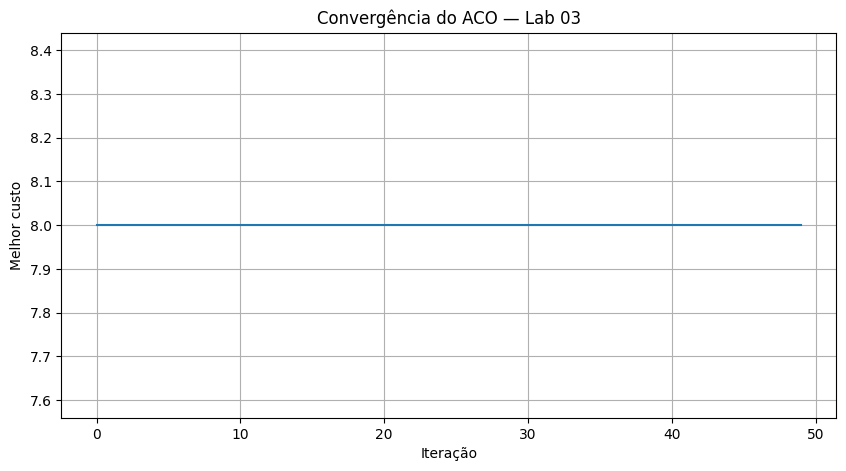

In [ ]:
# 7. Execução
melhor_rota = None
melhor_custo = float("inf")
historico = []

for iteracao in range(NUM_ITERACOES):
    rotas = []

    for _ in range(NUM_FORMIGAS):
        rota = construir_rota()
        if rota is not None:
            custo = calcular_custo(rota)
            rotas.append((rota, custo))
            if custo < melhor_custo:
                melhor_custo = custo
                melhor_rota = rota.copy()

    evaporar_feromonio()

    for rota, custo in rotas:
        depositar_feromonio(rota, custo)

    historico.append(melhor_custo)

print("Melhor rota:", melhor_rota)
print("Melhor custo:", melhor_custo)

plt.figure(figsize=(10, 5))
plt.plot(historico)
plt.xlabel("Iteração")
plt.ylabel("Melhor custo")
plt.title("Convergência do ACO — Lab 03")
plt.grid()
plt.show()